In [1]:
! git checkout -f module-14

Already on 'module-14'


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import YouTubeVideo, display, Image

%matplotlib inline


In [3]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [4]:
URL = r"https://www.dropbox.com/s/089r2yg6aao858l/opencv_bootcamp_assets_NB14.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB14.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path) 

In [5]:
protoFile = "pose_deploy_linevec_faster_4_stages.prototxt"
weightsFile = os.path.join("model", "pose_iter_160000.caffemodel")

In [6]:
npoints = 15
POSE_PAIRS = [
    [0,1],
    [1,2],
    [2,3],
    [3,4],
    [1,5],
    [5,6],
    [6,7],
    [1,14],
    [14,8],
    [8,9],
    [9,10],
    [14,11],
    [11,12],
    [12,13],
]

# Loading the model 

In [20]:
net = cv2.dnn.readNetFromCaffe(protoFile, weightsFile)

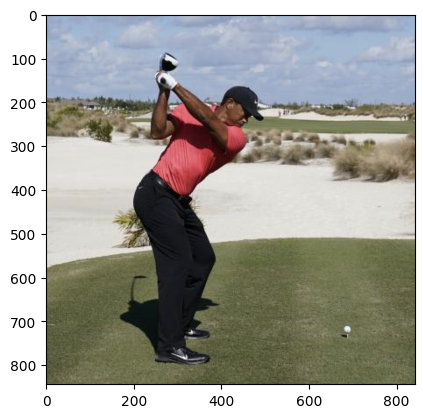

In [28]:
img = cv2.imread("Tiger_Woods_crop.png", cv2.IMREAD_COLOR)

frame_height = img.shape[0]
frame_width = img.shape[1]
plt.imshow(img[:,:,::-1])

# Converting Image to blob

In [29]:
input_size = (368, 368)

In [30]:
blob = cv2.dnn.blobFromImage(img, 1.0/255, size = input_size, mean = (0,0,0), swapRB =False, crop = False  )

# Run Inference (Forward Pass)

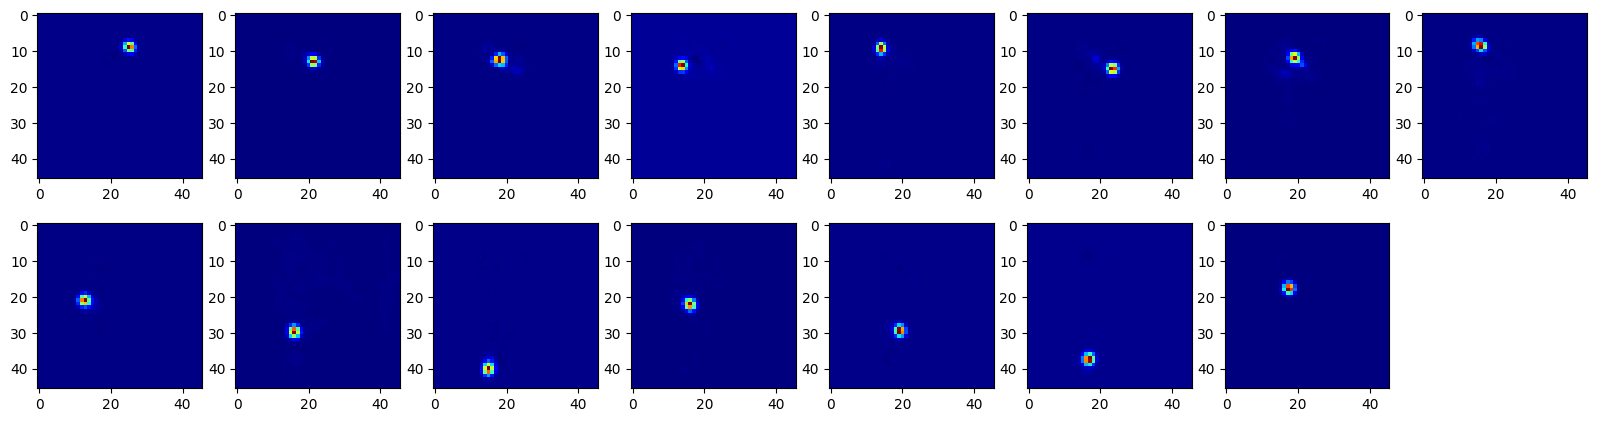

In [31]:
net.setInput(blob)
output = net.forward()

plt.figure(figsize = [20,5])
for i in range(npoints):
    probMap = output[0,i, :,:]
    plt.subplot(2, 8, i+1)
    plt.imshow(probMap, cmap  ="jet")

# Extract Points

In [32]:
scaleX = frame_width / output.shape[3]
scaleY = frame_height / output.shape[2]

points = []

threshold = 0.1

for i in range(npoints):
    probMap = output[0, i, :, :]

    min_val, max_val, min_loc, max_loc =  cv2.minMaxLoc(probMap)

    x = scaleX*max_loc[0]
    y = scaleY*max_loc[1]

    if max_val > threshold:
        points.append((int(x), int(y)))
    else :
        points.append(None)




# display points and skeleton

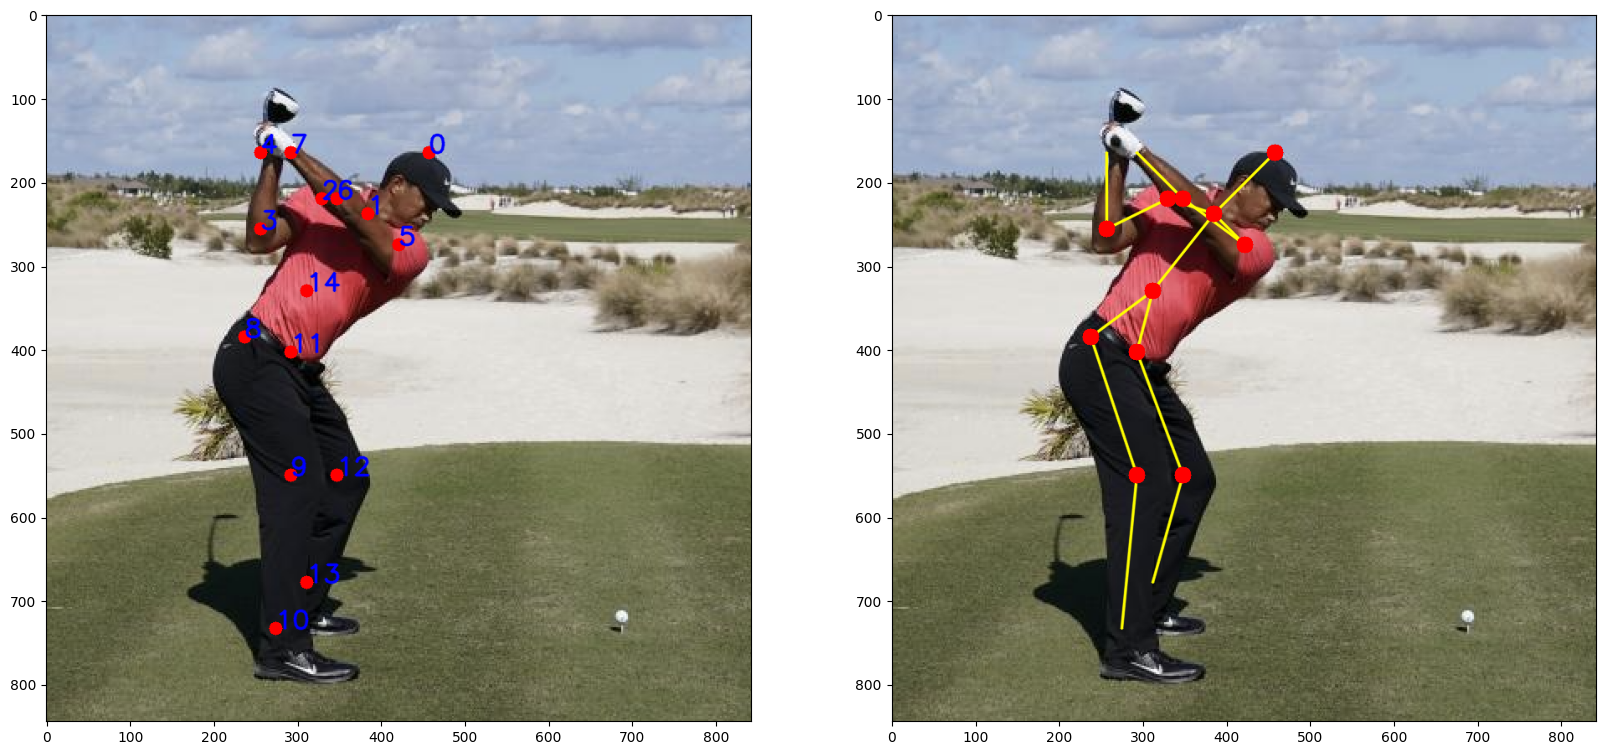

In [33]:
imgPoints = img.copy()
imgSkeleton = img.copy()

for i, p in enumerate(points):
    cv2.circle(imgPoints, p, 8, (0,0,255), thickness = -1)
    cv2.putText(imgPoints, "{}".format(i), p, cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2, lineType =cv2.LINE_AA )

for pair in POSE_PAIRS:
    partA , partB = pair[0], pair[1]

    point1 = points[partA]
    point2 = points[partB]
    if point1 and point2:
        cv2.line(imgSkeleton, point1, point2, (0, 255, 255), 2, lineType = cv2.LINE_AA)
        cv2.circle(imgSkeleton, point1, 10 , (0,0,255), -1)
    
plt.figure(figsize = [20,10])

plt.subplot(121)
plt.imshow(imgPoints[:,:,::-1])

plt.subplot(122); plt.imshow(imgSkeleton[:,:,::-1])

In [18]:
! git status


On branch module-14
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   Tiger_Woods_crop.png
	new file:   deploy.prototxt
	new file:   models/models/models/coco_class_labels.txt
	new file:   models/models/models/images/000000001000.jpg
	new file:   models/models/models/images/baseball.jpg
	new file:   models/models/models/images/giraffe-zebra.jpg
	new file:   models/models/models/images/soccer.jpg
	new file:   models/models/models/images/street.jpg
	new file:   models/models/models/models/.ipynb_checkpoints/ssd_mobilenet_v2_coco_2018_03_29-checkpoint.pbtxt
	new file:   models/models/models/models/ssd_mobilenet_v2_coco_2018_03_29.pbtxt
	new file:   models/models/models/models/ssd_mobilenet_v2_coco_2018_03_29/checkpoint
	new file:   models/models/models/models/ssd_mobilenet_v2_coco_2018_03_29/frozen_inference_graph.pb
	new file:   models/models/models/models/ssd_mobilenet_v2_coco_2018_03_29/model.ckpt.data-00000-of-00001
	new file:   models/models/mo

In [14]:
! git add module-14.ipynb Tiger_Woods_crop.png

In [15]:
! git commit -m "Complete module-14: Pose Detection"

[module-14 f8b0368] Complete module-14: Pose Detection
 24 files changed, 13879 insertions(+)
 create mode 100644 Tiger_Woods_crop.png
 create mode 100644 deploy.prototxt
 create mode 100644 models/models/models/coco_class_labels.txt
 create mode 100644 models/models/models/images/000000001000.jpg
 create mode 100644 models/models/models/images/baseball.jpg
 create mode 100644 models/models/models/images/giraffe-zebra.jpg
 create mode 100644 models/models/models/images/soccer.jpg
 create mode 100644 models/models/models/images/street.jpg
 create mode 100644 models/models/models/models/.ipynb_checkpoints/ssd_mobilenet_v2_coco_2018_03_29-checkpoint.pbtxt
 create mode 100644 models/models/models/models/ssd_mobilenet_v2_coco_2018_03_29.pbtxt
 create mode 100644 models/models/models/models/ssd_mobilenet_v2_coco_2018_03_29/checkpoint
 create mode 100644 models/models/models/models/ssd_mobilenet_v2_coco_2018_03_29/frozen_inference_graph.pb
 create mode 100644 models/models/models/models/ssd_m

In [37]:
! git push origin module-14

remote: warning: See https://gh.io/lfs for more information.        
remote: warning: File bbcaa534af6f4e808692f6096790c3377ff9bf4a is 66.75 MB; this is larger than GitHub's recommended maximum file size of 50.00 MB        
remote: warning: File 4f00c939c0fb6c3900bdb054cfa2c6c8976c81ea is 61.13 MB; this is larger than GitHub's recommended maximum file size of 50.00 MB        
remote: warning: File a0def1a051df64d129e496cef98859fcf1c877c2 is 66.46 MB; this is larger than GitHub's recommended maximum file size of 50.00 MB        
remote: warning: File 854bf489b2858fcb563c6f130ae339206ab5d39a is 64.38 MB; this is larger than GitHub's recommended maximum file size of 50.00 MB        
remote: warning: GH001: Large files detected. You may want to try Git Large File Storage - https://git-lfs.github.com.        
remote: 
remote: Create a pull request for 'module-14' on GitHub by visiting:        
remote:      https://github.com/omkarbelote10/opencv-bootcamp/pull/new/module-14        
remote: 


In [16]:
! git log --oneline

f8b0368 Complete module-14: Pose Detection
0c87e44 Initial commit: Setup main branch


In [17]:
! git reset --soft HEAD~1